# Rainfall scenarios

Generates uniform (spatially homogeneous) 2D rainfall scenarios as `.bc` files, and
swaps a chosen one into the exported D-HYDRO model.

The model built by `template.ipynb` contains a `[Meteo]` block in `bnd.ext` that points
at `rainfall.bc`. That block only names the file - it holds none of the rainfall values -
so a scenario is applied by overwriting `dflowfm/rainfall.bc` and nothing else. The grid,
the MDU and the boundary conditions stay frozen.

Run `template.ipynb` first. It writes a dry (zero-rain) `rainfall.bc` as the default, so a
run where the swap was forgotten produces no rain rather than silently reusing an old event.

**Units:** D-Flow FM expects the `rainfall` quantity in **mm/day**. Scenarios below are
specified in mm/h and converted on the way in.

All scenarios share one output directory (`dflowfm/output`), so each run overwrites the
previous one.

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt

from hydrolib.core.dflowfm.bc.models import ForcingModel, QuantityUnitPair, TimeSeries
from hydrolib.core.dflowfm.mdu.models import FMModel

# same paths as template.ipynb
data_path = Path("../tests/data/template/datasets").resolve()
output_path = data_path / "delft3d_model"

# library of generated scenarios, kept outside the model directory
scenario_path = data_path / "rainfall"
scenario_path.mkdir(parents=True, exist_ok=True)

# the file the [Meteo] block in bnd.ext points at
target_bc = output_path / "dflowfm" / "rainfall.bc"

assert output_path.exists(), f"model not found at {output_path} - run template.ipynb first"
print(f"scenarios : {scenario_path}")
print(f"target    : {target_bc}")

scenarios : G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\rainfall
target    : G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\delft3d_model\dflowfm\rainfall.bc


## Simulation window

Read back from the exported MDU rather than hardcoded, so the scenarios cannot drift out of
sync with the model. Every scenario must fit inside this window and use this reference date -
a scenario longer than the window would need `fm.time.tstop` changed in `template.ipynb`,
which puts you outside the swap-only workflow.

In [2]:
fm_ref = FMModel(filepath=output_path / "dflowfm" / "DFM.mdu")

refdate = str(fm_ref.time.refdate)  # yyyymmdd as int in the MDU
refdate_str = f"{refdate[:4]}-{refdate[4:6]}-{refdate[6:8]} 00:00:00"
time_unit = f"minutes since {refdate_str}"

tstart_min = fm_ref.time.tstart / 60.0
tstop_min = fm_ref.time.tstop / 60.0

if not fm_ref.external_forcing.rainfall:
    print(
        "WARNING: Rainfall is not enabled in the MDU. Set fm.external_forcing.rainfall = True\n"
        "         in template.ipynb, or D-Flow FM will parse the [Meteo] block and ignore it."
    )

print(f"refdate : {refdate_str}")
print(f"window  : {tstart_min:.0f} - {tstop_min:.0f} min ({tstop_min / 60:.1f} h)")

refdate : 2016-06-01 00:00:00
window  : 0 - 2880 min (48.0 h)


## Scenario definition

A block event: constant intensity for `duration_h`, dry before and after. The duplicated
timestamp at the end of the burst is what makes it a step rather than a linear ramp down
over the rest of the run; `block-To` interpolation gives the same shape, and the duplicate
keeps the file correct even if the kernel falls back to linear.

(`block-To` is the spelling hydrolib-core 1.0.1 accepts - the enum is
`['linear', 'block-From', 'block-To']`, not the `blockTo` seen in the D-Flow FM manual.)

In [3]:
def rain_datablock(intensity_mm_h, duration_h, start_h=0.0):
    """Block rainfall event as [[time_min, mm/day], ...] spanning the full window."""
    start_min = start_h * 60.0
    end_min = start_min + duration_h * 60.0
    intensity_mm_day = intensity_mm_h * 24.0  # D-Flow FM wants mm/day

    if end_min > tstop_min:
        raise ValueError(
            f"event ends at {end_min:.0f} min, beyond tstop {tstop_min:.0f} min - "
            "shorten the event or raise fm.time.tstop in template.ipynb"
        )

    block = [[tstart_min, 0.0]] if start_min > tstart_min else []
    block += [
        [start_min, intensity_mm_day],
        [end_min, intensity_mm_day],
        [end_min, 0.0],
        [tstop_min, 0.0],
    ]
    return block


def write_scenario(name, datablock):
    """Write one scenario .bc into the library. The scenario name is stored in the
    TimeSeries name field, so the active file stays identifiable after the swap."""
    filepath = scenario_path / f"{name}.bc"
    ForcingModel(
        forcing=[
            TimeSeries(
                name="global",
                function="timeseries",
                timeinterpolation="block-To",
                quantityunitpair=[
                    QuantityUnitPair(quantity="time", unit=time_unit),
                    QuantityUnitPair(quantity="rainfall", unit="mm day-1"),
                ],
                datablock=datablock,
            )
        ]
    ).save(filepath=filepath)
    return filepath

## Build the library

Edit the table below to define scenarios: `name -> (intensity mm/h, duration h, start h)`.
The `dry` case is a useful control - it reproduces the model's default state.

In [4]:
scenarios = {
    "dry": (0.0, 0.0, 0.0),
    "50mmh_2h": (50.0, 2.0, 0.0),
    "25mmh_4h": (25.0, 4.0, 0.0),
    "100mmh_1h": (100.0, 1.0, 0.0),
    "100mmh_24h": (100.0, 24.0, 0.0),
    "50mmh_2h_delayed": (50.0, 2.0, 6.0),  # starts 6 h into the run
}

for name, (intensity, duration, start) in scenarios.items():
    filepath = write_scenario(name, rain_datablock(intensity, duration, start))
    total_mm = intensity * duration
    print(f"{name:20s} {intensity:6.1f} mm/h x {duration:4.1f} h = {total_mm:6.1f} mm total")

dry                     0.0 mm/h x  0.0 h =    0.0 mm total
50mmh_2h               50.0 mm/h x  2.0 h =  100.0 mm total
25mmh_4h               25.0 mm/h x  4.0 h =  100.0 mm total
100mmh_1h             100.0 mm/h x  1.0 h =  100.0 mm total
100mmh_24h            100.0 mm/h x 24.0 h = 2400.0 mm total
50mmh_2h_delayed       50.0 mm/h x  2.0 h =  100.0 mm total


## Inspect

Plotted in mm/h for readability; the files hold mm/day.

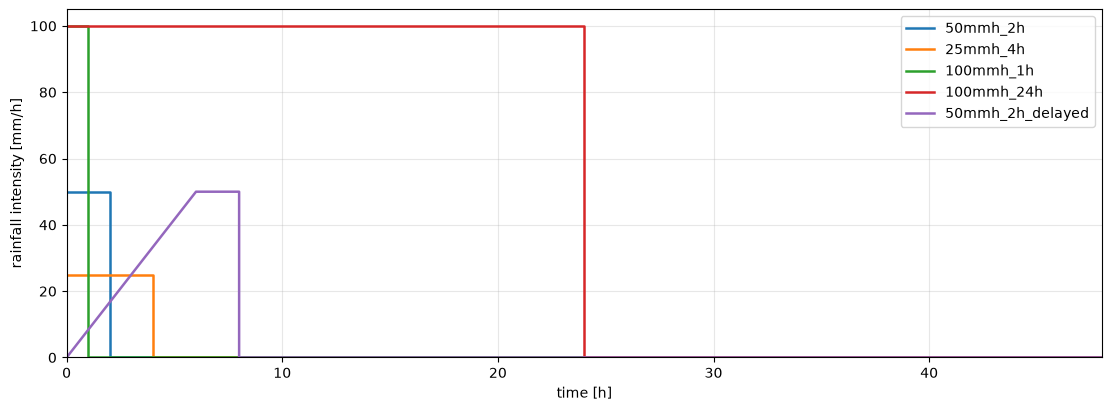

In [5]:
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)

for name, (intensity, duration, start) in scenarios.items():
    if intensity == 0.0:
        continue
    block = rain_datablock(intensity, duration, start)
    hours = [row[0] / 60.0 for row in block]
    mm_h = [row[1] / 24.0 for row in block]
    ax.plot(hours, mm_h, linewidth=1.8, label=name)

ax.set_xlabel("time [h]")
ax.set_ylabel("rainfall intensity [mm/h]")
ax.set_xlim(tstart_min / 60.0, tstop_min / 60.0)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## Apply a scenario

Copies the chosen `.bc` over `dflowfm/rainfall.bc`. Nothing else in the model is touched,
so after this the model is ready to run via `run.bat` in the model directory.

Re-running `template.ipynb` regenerates `rainfall.bc` as dry - re-apply afterwards.

In [6]:
def apply_scenario(name):
    source = scenario_path / f"{name}.bc"
    if not source.exists():
        raise FileNotFoundError(f"{source} not found - run the library cell first")
    if not target_bc.exists():
        raise FileNotFoundError(
            f"{target_bc} not found. template.ipynb must write a default rainfall.bc "
            "(and the [Meteo] block in bnd.ext that refers to it) before scenarios can be swapped in."
        )
    shutil.copyfile(source, target_bc)
    return source


active = "100mmh_24h"
source = apply_scenario(active)

print(f"applied '{active}'")
print(f"  {source}")
print(f"  -> {target_bc}")
print(f"\nrun the model with: {output_path / 'run.bat'}")

applied '100mmh_24h'
  G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\rainfall\100mmh_24h.bc
  -> G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\delft3d_model\dflowfm\rainfall.bc

run the model with: G:\workspace\github\HYDROLIB\hydrolib\tests\data\template\datasets\delft3d_model\run.bat


## Verify what is currently applied

Every scenario lands at the same filename, so this reads the `name` field back out of the
file itself to confirm which one is in place.

## 

In [7]:
current = ForcingModel(filepath=target_bc)

for forcing in current.forcing:
    peak_mm_day = max(row[1] for row in forcing.datablock)
    print(f"active scenario : {forcing.name}")
    print(f"peak intensity  : {peak_mm_day:.1f} mm/day  ({peak_mm_day / 24:.1f} mm/h)")

print(f"\n--- {target_bc.name} ---")
print(target_bc.read_text())

active scenario : global
peak intensity  : 2400.0 mm/day  (100.0 mm/h)

--- rainfall.bc ---
# written by HYDROLIB-core 1.0.1

[General]
fileVersion = 1.01
fileType    = boundConds

[Forcing]
name              = global
function          = timeseries
timeInterpolation = block-To
offset            = 0.0
factor            = 1.0
quantity          = time
unit              = minutes since 2016-06-01 00:00:00
quantity          = rainfall
unit              = mm day-1
0.0     2400.0
1440.0  2400.0
1440.0  0.0
2880.0  0.0


